# 📊 Análise das Hipóteses da Regressão Linear

Este notebook contém a análise das hipóteses de Regressão Linear (Linearidade, Homoscedasticidade, Normalidade dos Resíduos e Multicolinearidade) para os ativos analisados.


## 📂 Carregar Dados

In [1]:
import os
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from scipy import stats
import statsmodels.api as sm
from statsmodels.stats.diagnostic import het_breuschpagan
from statsmodels.stats.outliers_influence import variance_inflation_factor

model_dir = "../saved_models"
version = "1.1"
ativos = ['ITUB4', 'BBAS3', 'CYRE3', 'TEND3', 'DIRR3', 'ELET3', 'EQTL3', 'CMIG4', 'PETR3', 'VALE3', 'BRAP3']

## Testes aplicados

### **Breusch-Pagan Teste de Homoscedasticidade**  
Este teste verifica se os resíduos do modelo apresentam **variância constante** (hipótese de homoscedasticidade).  
- **p-valor > 0.05**: Aceita a hipótese nula de homoscedasticidade (bom para o modelo linear).  
- **p-valor < 0.05**: Rejeita a hipótese nula — indica **heteroscedasticidade** (variância não constante), o que pode prejudicar inferências estatísticas.  

⚠️ **No nosso contexto (previsão de preços de ativos financeiros)**, a presença de heteroscedasticidade é **comum** e **não invalida o modelo preditivo**. É um alerta para análise estatística clássica, mas para previsão prática, o impacto pode ser limitado.

### **Shapiro-Wilk Teste de Normalidade dos Resíduos**  
Este teste verifica se os resíduos seguem uma **distribuição normal**.  
- **p-valor > 0.05**: Aceita a hipótese nula de normalidade (bom para modelos lineares clássicos).  
- **p-valor < 0.05**: Rejeita a hipótese nula — indica que os resíduos **não são normalmente distribuídos**.  

⚠️ **Em séries financeiras, é esperado que os resíduos não sejam normais** devido à natureza caótica e às variações do mercado.  
Para previsão, **a normalidade não é obrigatória** — o mais importante é a capacidade do modelo prever corretamente os valores de interesse.

### **Variance Inflation Factor (VIF) — Multicolinearidade**  
O VIF mede quanto uma variável independente (lag) é explicada pelas outras.  
- **VIF < 5**: Multicolinearidade fraca (ideal).  
- **VIF entre 5 e 10**: Multicolinearidade moderada.  
- **VIF > 10**: Multicolinearidade severa — os lags estão altamente correlacionados.

⚠️ **Em modelos baseados em lags de séries temporais**, é **esperado que os lags sejam altamente correlacionados** (alta multicolinearidade).  
Isso **não é um problema para previsão**, mas **afeta a interpretação dos coeficientes** do modelo linear.



📈 Analisando ITUB4...


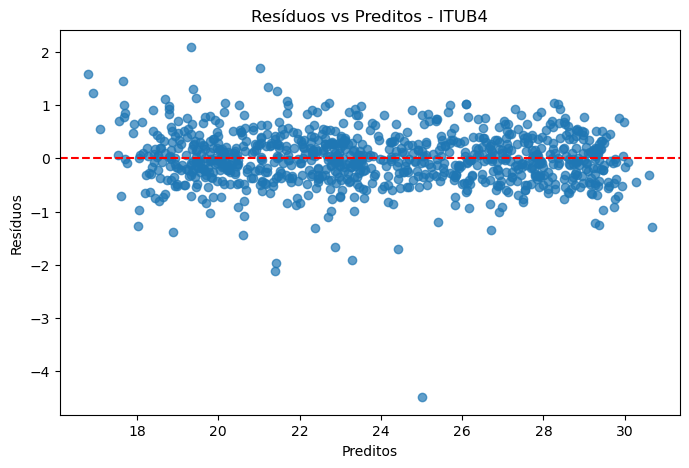

Breusch-Pagan p-valor: 0.2487


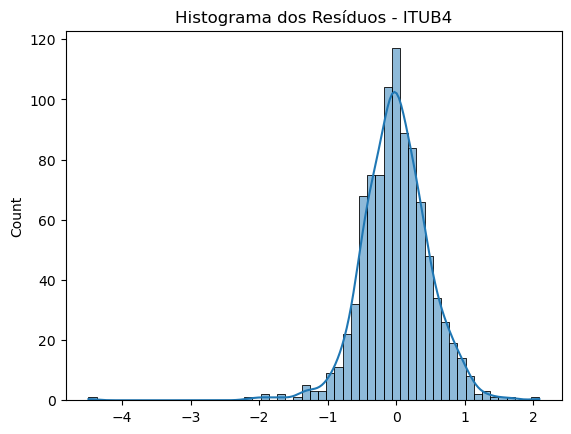

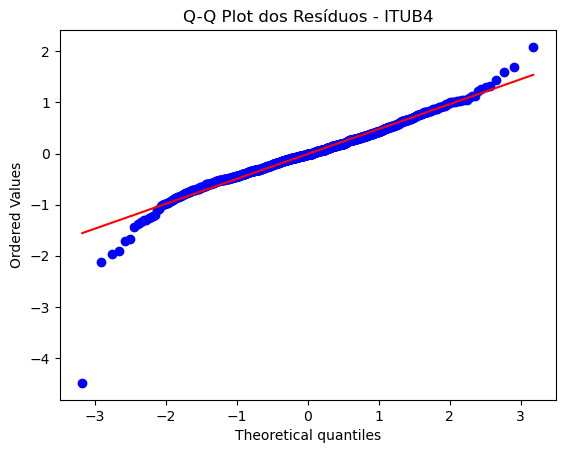

Shapiro-Wilk p-valor: 0.0000
  Feature          VIF
0   lag_1  1207.067246
1   lag_2  2228.131530
2   lag_3  1206.697040

📈 Analisando BBAS3...


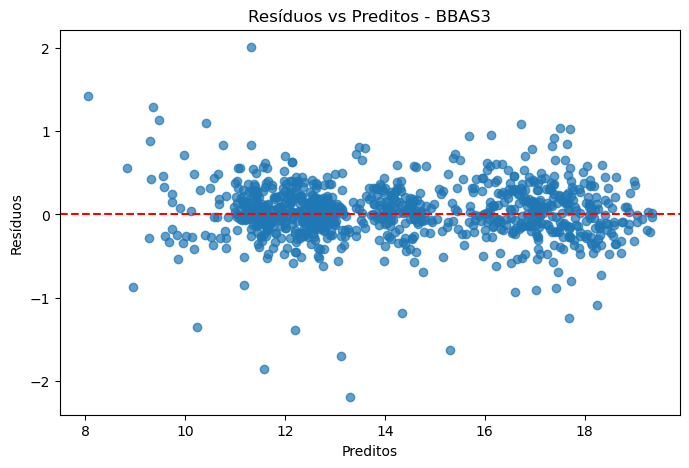

Breusch-Pagan p-valor: 0.3340


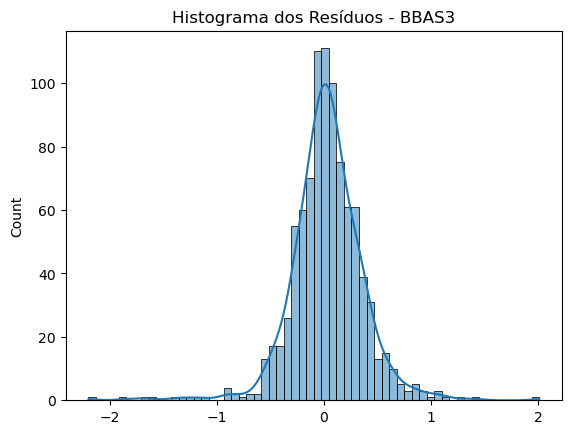

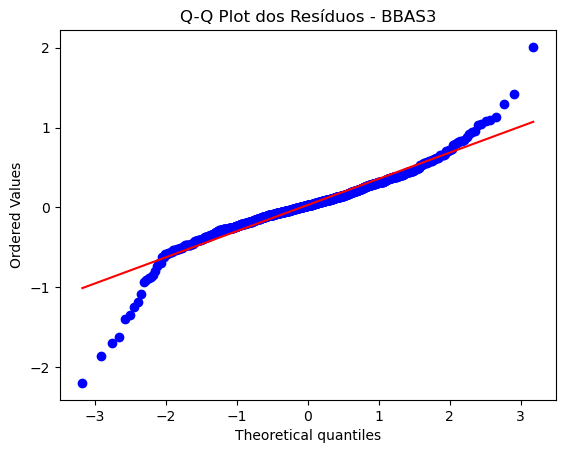

Shapiro-Wilk p-valor: 0.0000
  Feature          VIF
0   lag_1  1013.787997
1   lag_2  1845.624103
2   lag_3  1013.677449

📈 Analisando CYRE3...


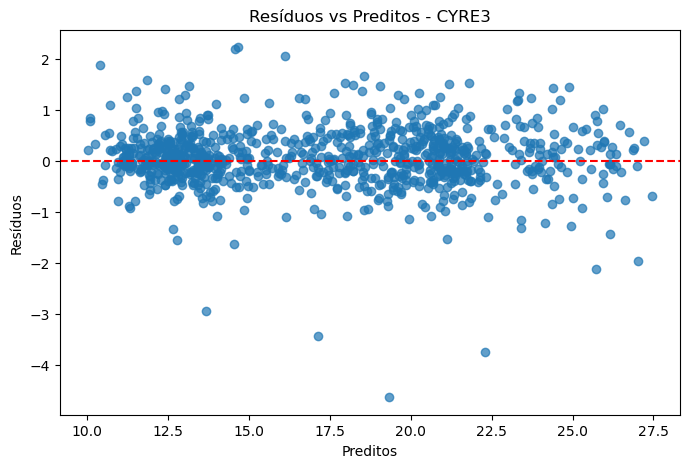

Breusch-Pagan p-valor: 0.0263


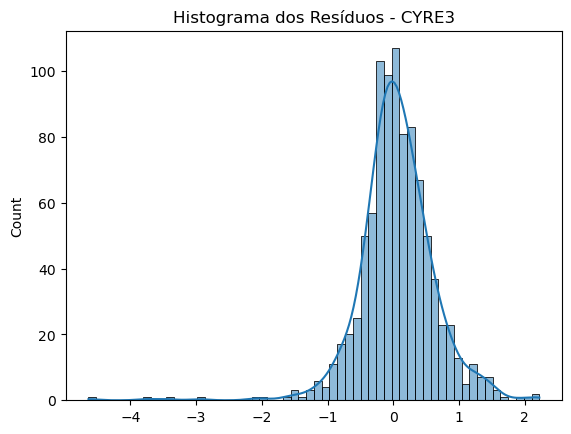

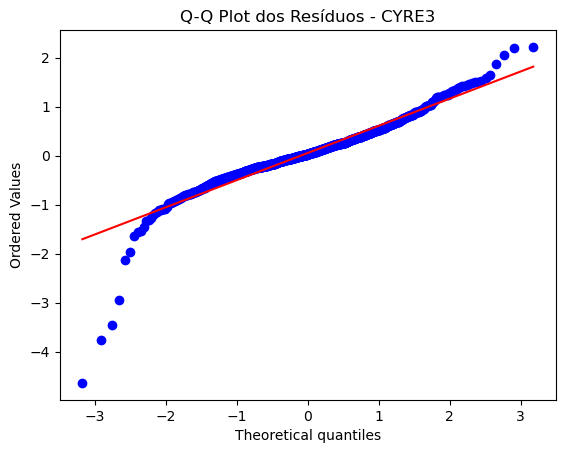

Shapiro-Wilk p-valor: 0.0000
  Feature          VIF
0   lag_1   540.954060
1   lag_2  1000.868945
2   lag_3   543.257041

📈 Analisando TEND3...


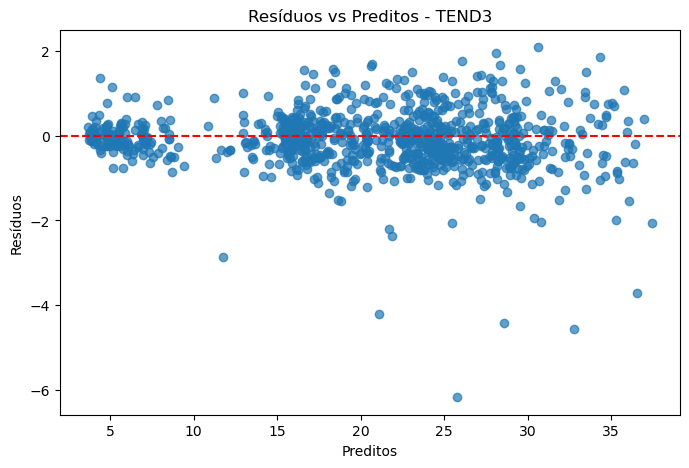

Breusch-Pagan p-valor: 0.0000


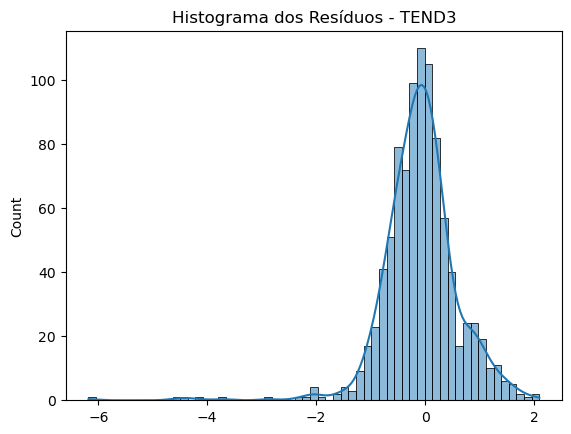

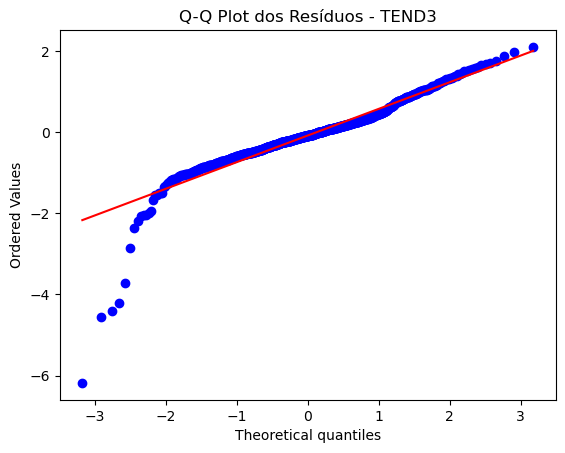

Shapiro-Wilk p-valor: 0.0000
  Feature          VIF
0   lag_1   713.847609
1   lag_2  1310.903447
2   lag_3   714.107245

📈 Analisando DIRR3...


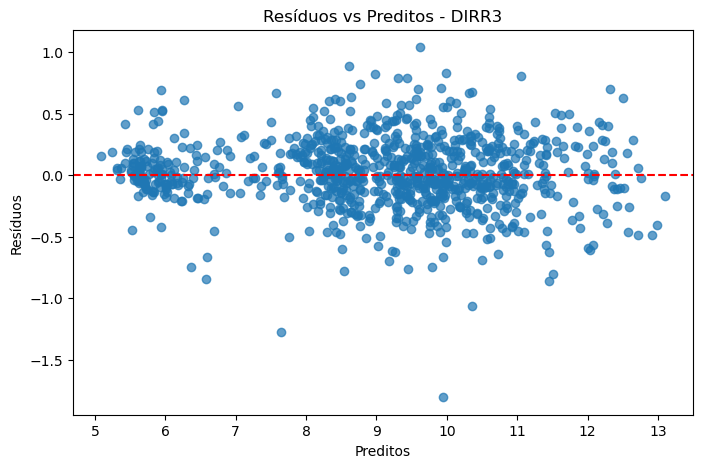

Breusch-Pagan p-valor: 0.0027


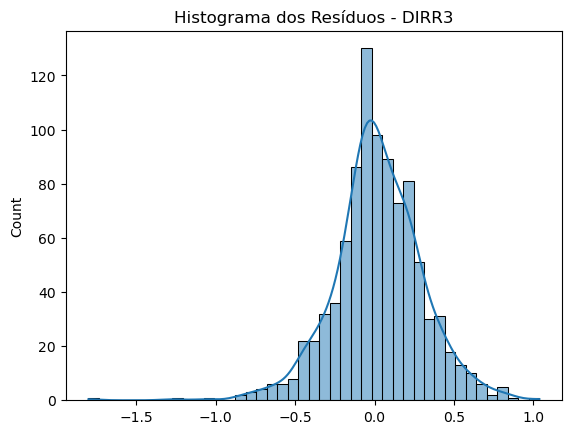

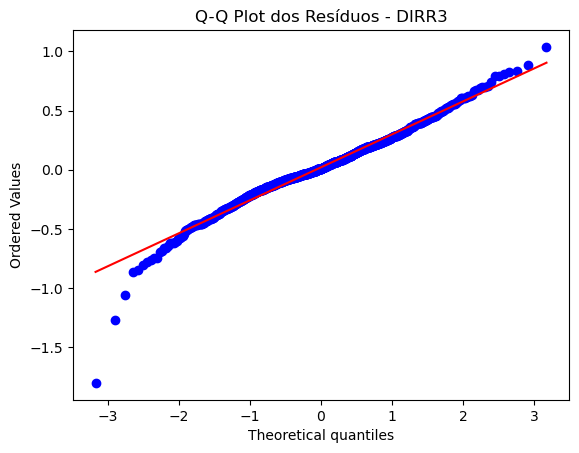

Shapiro-Wilk p-valor: 0.0000
  Feature          VIF
0   lag_1   715.417319
1   lag_2  1453.332847
2   lag_3   715.329750

📈 Analisando ELET3...


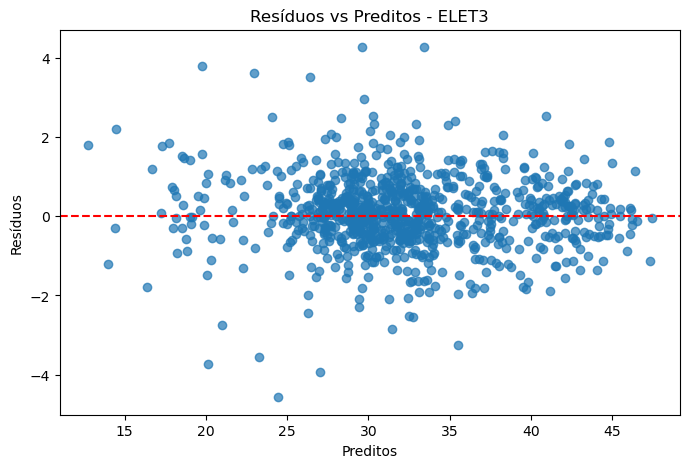

Breusch-Pagan p-valor: 0.0003


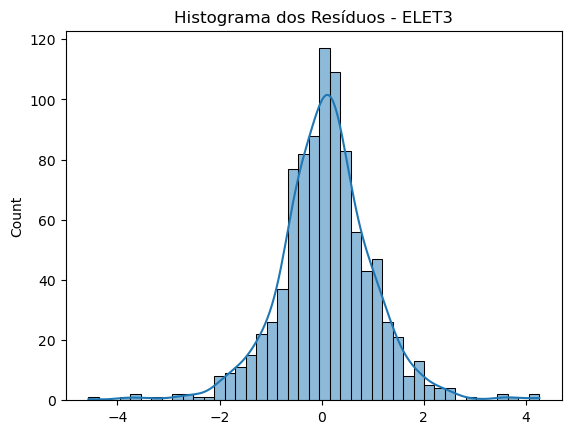

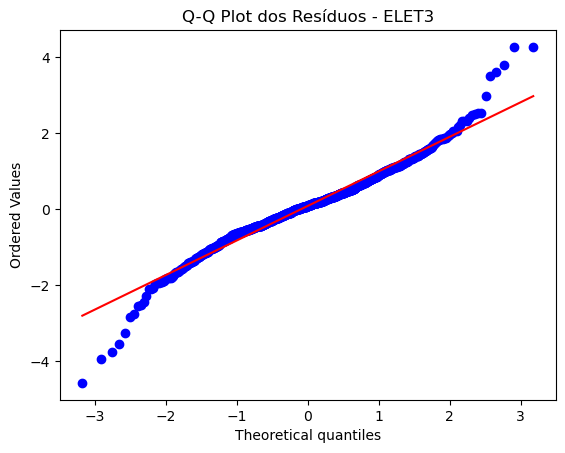

Shapiro-Wilk p-valor: 0.0000
  Feature          VIF
0   lag_1  1078.853895
1   lag_2  1974.328477
2   lag_3  1038.562061

📈 Analisando EQTL3...


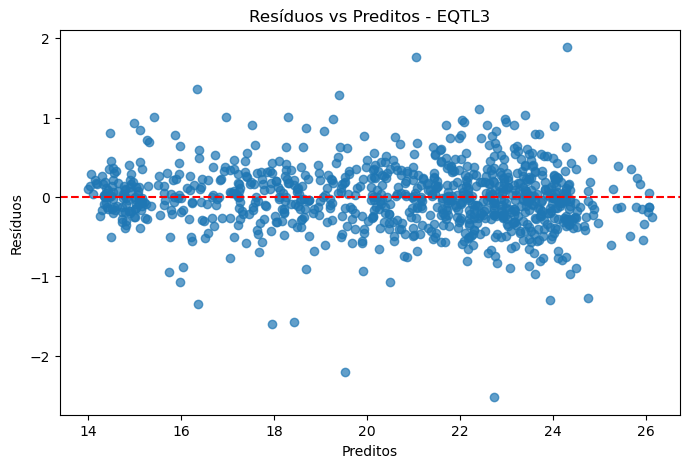

Breusch-Pagan p-valor: 0.1947


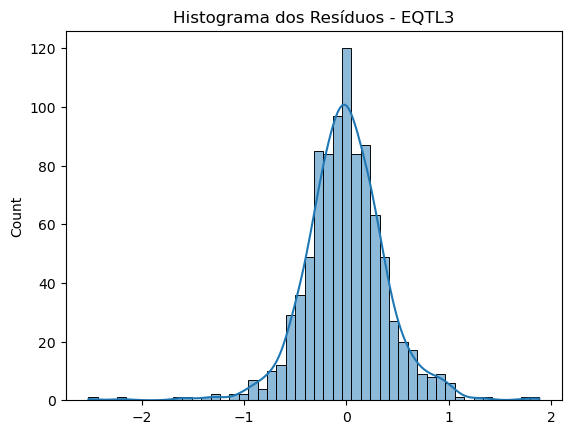

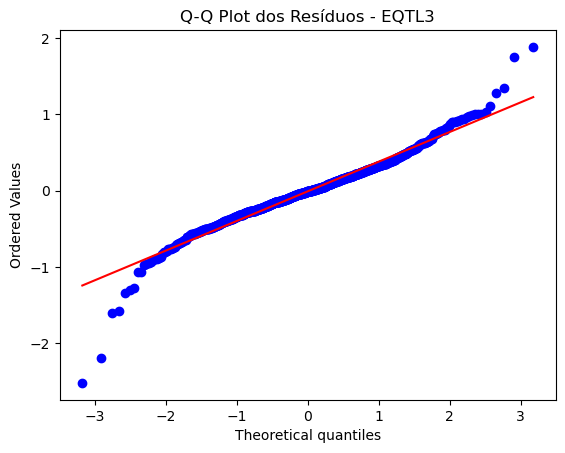

Shapiro-Wilk p-valor: 0.0000
  Feature          VIF
0   lag_1  2340.505855
1   lag_2  4265.914709
2   lag_3  2335.512112

📈 Analisando CMIG4...


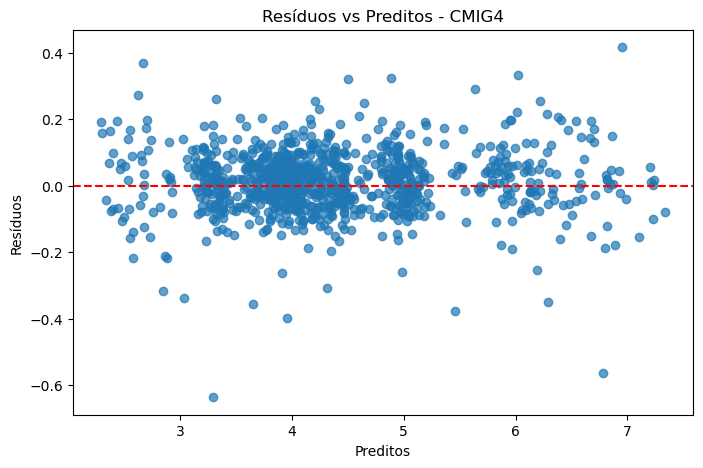

Breusch-Pagan p-valor: 0.1177


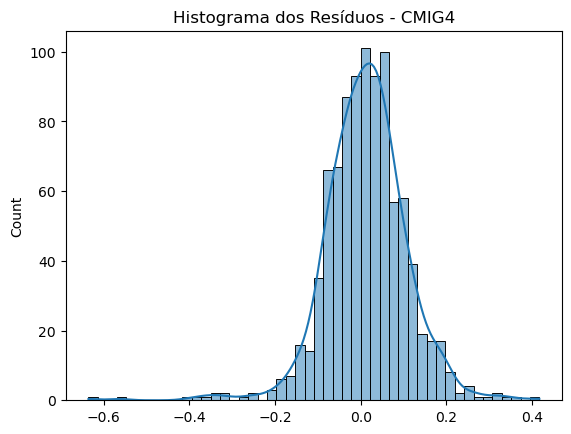

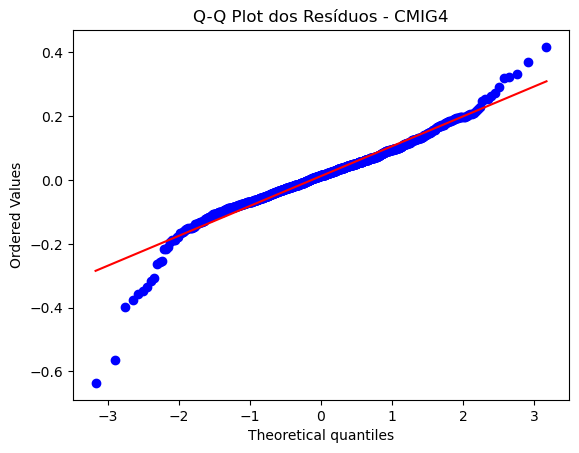

Shapiro-Wilk p-valor: 0.0000
  Feature          VIF
0   lag_1  1392.107440
1   lag_2  2654.503471
2   lag_3  1390.072658

📈 Analisando PETR3...


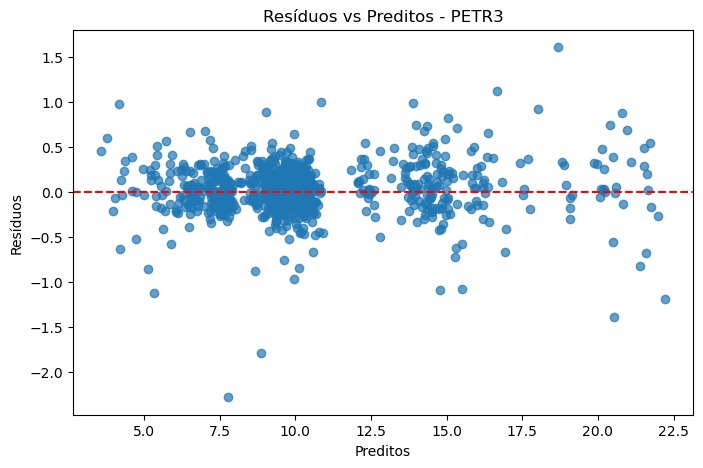

Breusch-Pagan p-valor: 0.0000


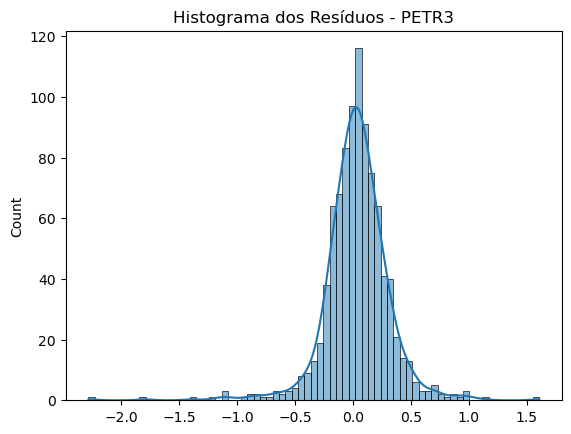

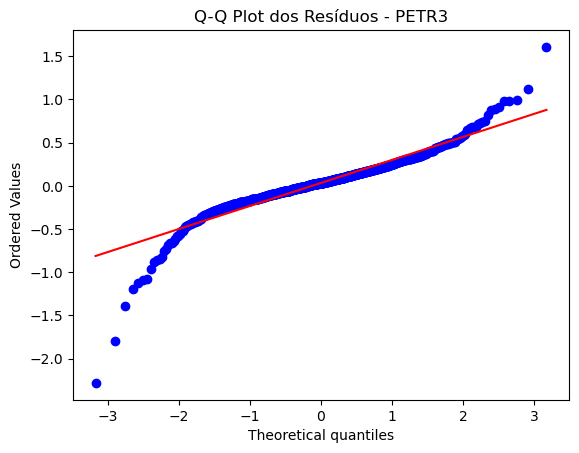

Shapiro-Wilk p-valor: 0.0000
  Feature          VIF
0   lag_1  1051.442278
1   lag_2  2016.637109
2   lag_3  1047.983256

📈 Analisando VALE3...


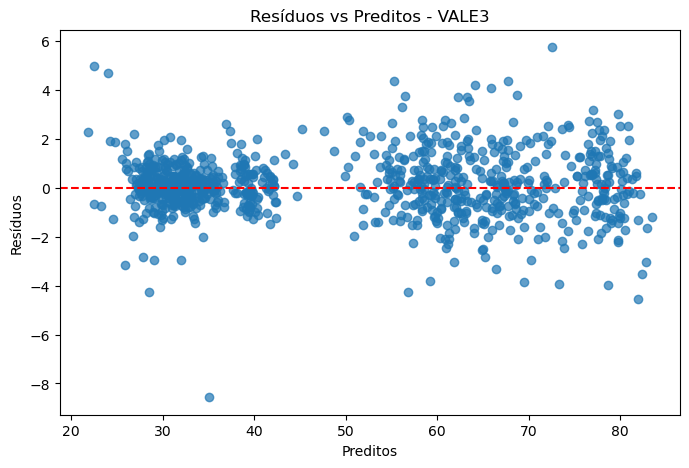

Breusch-Pagan p-valor: 0.0000


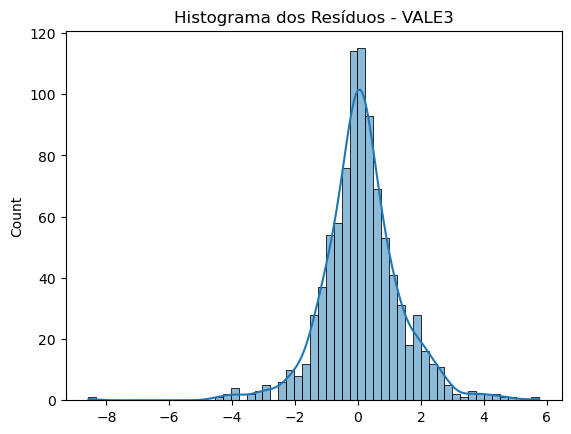

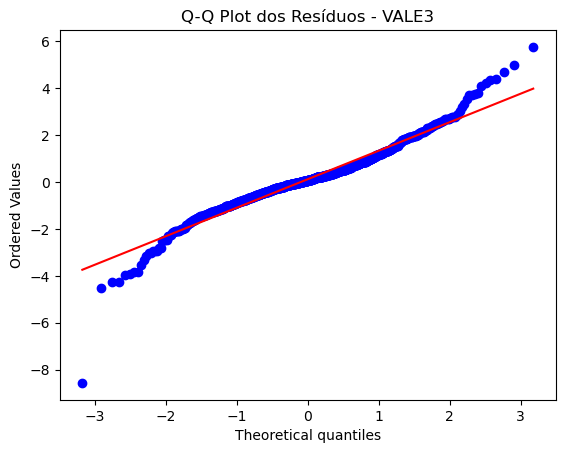

Shapiro-Wilk p-valor: 0.0000
  Feature          VIF
0   lag_1  1503.522887
1   lag_2  2929.018350
2   lag_3  1500.481231

📈 Analisando BRAP3...


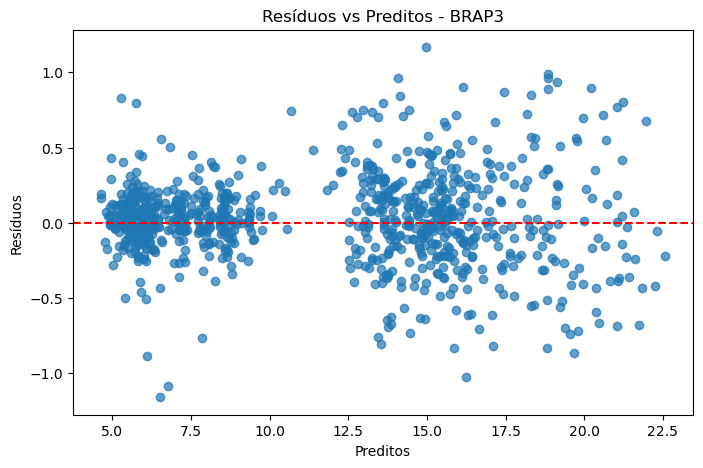

Breusch-Pagan p-valor: 0.0000


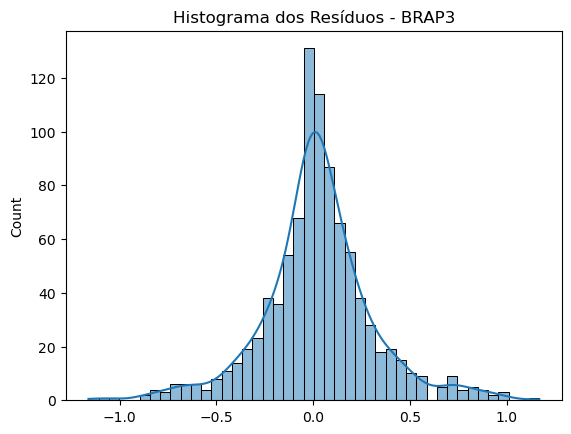

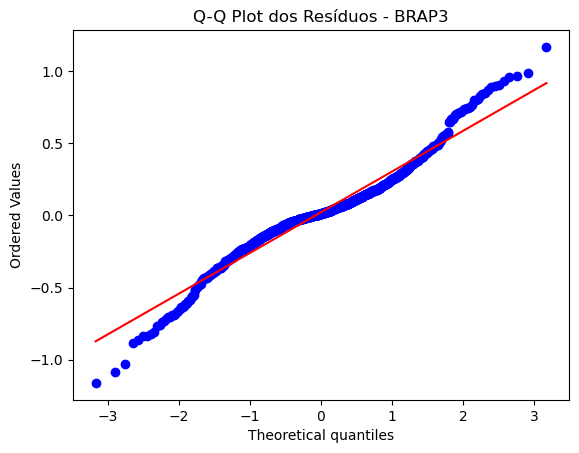

Shapiro-Wilk p-valor: 0.0000
  Feature          VIF
0   lag_1  1737.525279
1   lag_2  3644.965145
2   lag_3  1733.428613


In [2]:
for ativo in ativos:
    print(f"\n📈 Analisando {ativo}...")
    y_test = np.load(os.path.join(model_dir, f"{ativo}_y_test_v{version}.npy"))
    y_pred = np.load(os.path.join(model_dir, f"{ativo}_y_pred_v{version}.npy"))
    X_test_norm = np.load(os.path.join(model_dir, f"{ativo}_X_test_norm_v{version}.npy"))

    residuals = y_test - y_pred

    # Resíduos vs Preditos
    plt.figure(figsize=(8,5))
    plt.scatter(y_pred, residuals, alpha=0.7)
    plt.axhline(0, color='red', linestyle='--')
    plt.xlabel('Preditos')
    plt.ylabel('Resíduos')
    plt.title(f'Resíduos vs Preditos - {ativo}')
    plt.show()

    # Teste de Breusch-Pagan
    X_test_sm = sm.add_constant(y_pred)
    bp_test = het_breuschpagan(residuals, X_test_sm)
    print(f"Breusch-Pagan p-valor: {bp_test[1]:.4f}")

    # Histograma dos Resíduos
    sns.histplot(residuals, kde=True)
    plt.title(f'Histograma dos Resíduos - {ativo}')
    plt.show()

    # Q-Q Plot
    stats.probplot(residuals, dist="norm", plot=plt)
    plt.title(f'Q-Q Plot dos Resíduos - {ativo}')
    plt.show()

    # Shapiro-Wilk
    shapiro = stats.shapiro(residuals)
    print(f"Shapiro-Wilk p-valor: {shapiro.pvalue:.4f}")

    # VIF (se aplicável)
    if X_test_norm.shape[1] > 1:
        X_test_df = pd.DataFrame(X_test_norm, columns=[f'lag_{i}' for i in range(1, X_test_norm.shape[1]+1)])
        vif_data = pd.DataFrame()
        vif_data['Feature'] = X_test_df.columns
        vif_data['VIF'] = [variance_inflation_factor(X_test_df.values, i) for i in range(X_test_df.shape[1])]
        print(vif_data)